### MLOps Assignment 2 : Design and implement an end-to-end MLOps pipeline for model building, artifact/image creation, packaging, containerization, and CI/CD-based deployment using open-source tools

### Use case : 

Binary image classification (Cats vs Dogs) for a pet adoption platform.

### Group ID: 82
### Group members

| Name           | Email                                       | Student ID   | Contribution |
|----------------|---------------------------------------------|--------------|--------------|
| JAIDEEP PALIT  | 2024aa05319@wilp.bits-pilani.ac.in          | 2024aa05319  | 100%         |
|  OMKAR ANIL KUMAR | 2024ac05308@wilp.bits-pilani.ac.in         | 2024ac05308 |100%|
|  PALLAB KUMAR GHOSHAL  | 2024ab05312@wilp.bits-pilani.ac.in         | 2024ab05312 |100%|
|PANKAJ KUMAR  |2024ab05026@wilp.bits-pilani.ac.in   |2024ab05026|100%|
|PRASANNA B|2024ab05310@wilp.bits-pilani.ac.in|2024ab05310|100%|

### Problem Statement

Design and implement an end-to-end MLOps pipeline for model building, artifact/image creation, packaging, containerization, and CI/CD-based deployment using open-source tools

### Dataset:
Title: Cats and Dogs classification dataset

Source: CATS and Dogs binary classification dataset from Kaggle - https://www.kaggle.com/datasets/bhavikjikadara/dog-and-cat-classification-dataset



### Task 1: Data Acquisition, Preprocessing & Exploratory Data Analysis (EDA)

Obtain the dataset. Pre-process to 224x224 RGB images for standard CNNs. Perform EDA with professional visualizations (histograms, correlation heatmaps, class balance).

#### Import Libraries

In [18]:
!pip install -r ../requirements.txt

#### Download the Dataset

In [19]:
import warnings
warnings.filterwarnings("ignore")

In [20]:
from preprocess.preprocess import download_dataset
data_dir=download_dataset(url="bhavikjikadara/dog-and-cat-classification-dataset",download_path="cats_and_dogs_classification_data")

Path to dataset files: /home/jai/Desktop/code/mlops/bits-mtech-mlops-assignment-2/data/raw/cats_and_dogs_classification_data


#### Exploratory Data Analysis (EDA)

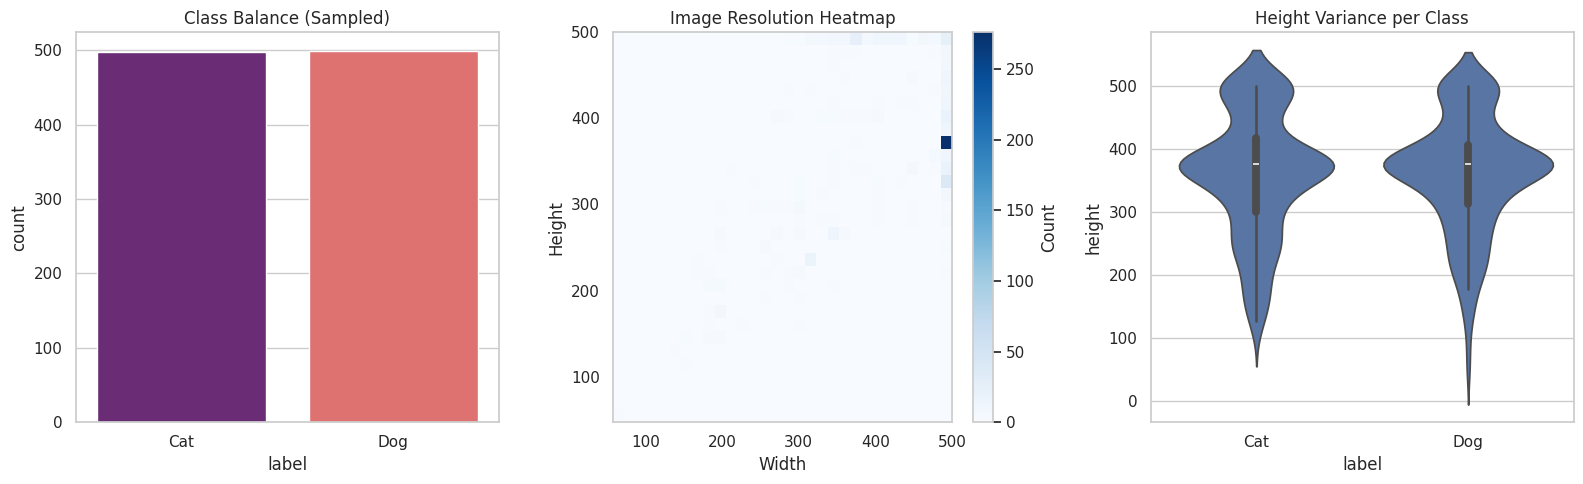

In [21]:
from preprocess.eda import eda_class_bal_image_res_channel_check
eda_class_bal_image_res_channel_check(data_dir=data_dir)


Analyzing Dog: 100%|██████████| 1000/1000 [00:00<00:00, 2817.37it/s]


<Figure size 1000x800 with 0 Axes>

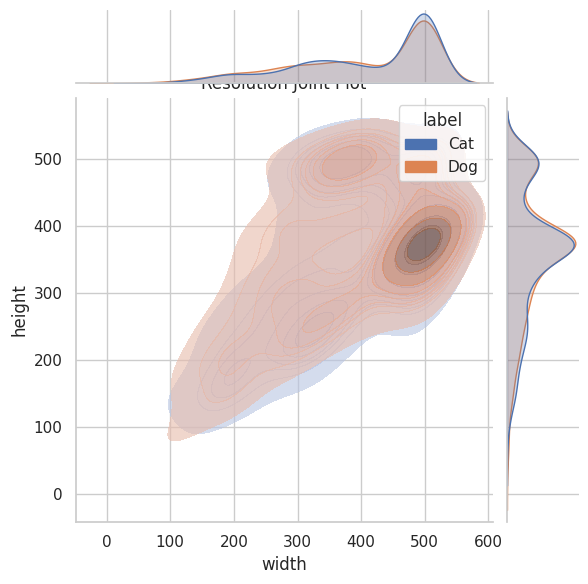

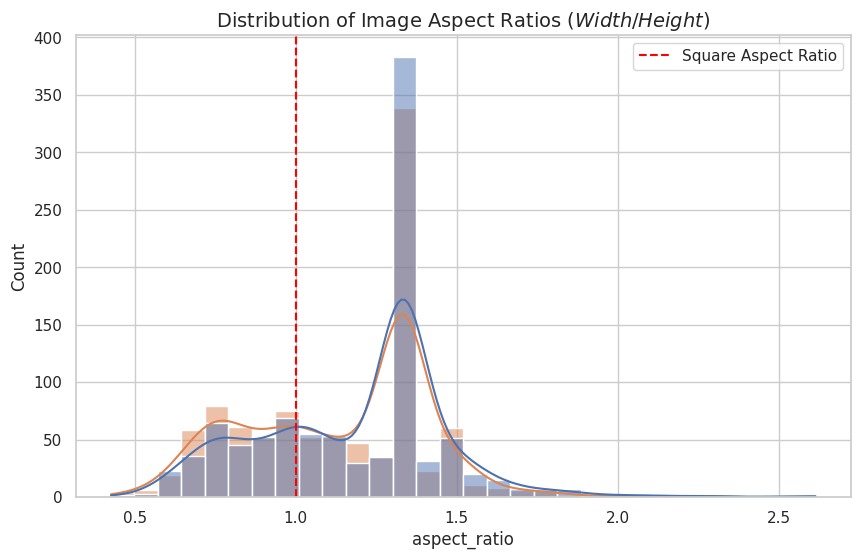

In [22]:
from preprocess.eda import perform_eda_res_disjoint_aspect_ratio
df_stats = perform_eda_res_disjoint_aspect_ratio(data_dir)


### Pre-process to 224x224 RGB images for standard CNNs
#### Train–Test Split

In [23]:
from preprocess.preprocess import pre_process_dataset
pre_process_dataset(data_dir=data_dir)

Processing Dog for test: 100%|██████████| 1250/1250 [00:00<00:00, 1420.97it/s]


✅ Dataset saved successfully at: /home/jai/Desktop/code/mlops/bits-mtech-mlops-assignment-2/data/preprocessed/preprocessed_cats_dogs_images


##### Data versioning with DVC

In [24]:
# from preprocess.preprocess import data_versioning_with_dvc
# data_versioning_with_dvc()

In [25]:
# from preprocess.preprocess import git_dvc_version
# git_dvc_version()

### Model Building
Implement at least one baseline model (e.g., simple CNN or logistic regression on flattened pixels).
Save the trained model in a standard serialized format (e.g., .pkl, .pt, .h5).

##### Load dataset for training

In [26]:
from train.train_util import load_training_dataset
train_ds,val_ds=load_training_dataset()

Found 19953 files belonging to 2 classes.
Found 2498 files belonging to 2 classes.


In [1]:
from train.train_cnn import build_cnn,train_cnn
cnn_model=build_cnn()


/home/jai/Desktop/code/mlops/bits-mtech-mlops-assignment-2/.venv/lib/python3.11/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [2]:
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ ?                      │   0 (unbuilt) │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [29]:
history=train_cnn(model=cnn_model,train_ds=train_ds,val_ds=val_ds)


Epoch 1/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 636s 1s/step - accuracy: 0.6310 - loss: 0.6401 - val_accuracy: 0.6089 - val_loss: 0.6538
Epoch 2/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 625s 1s/step - accuracy: 0.6942 - loss: 0.5789 - val_accuracy: 0.7114 - val_loss: 0.5612
Epoch 3/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 659s 1s/step - accuracy: 0.7244 - loss: 0.5455 - val_accuracy: 0.6441 - val_loss: 0.7003
Epoch 4/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 669s 1s/step - accuracy: 0.7463 - loss: 0.5163 - val_accuracy: 0.6437 - val_loss: 0.7540
Epoch 5/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 643s 1s/step - accuracy: 0.7716 - loss: 0.4818 - val_accuracy: 0.7538 - val_loss: 0.5323
Epoch 6/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 626s 1s/step - accuracy: 0.7868 - loss: 0.4624 - val_accuracy: 0.7042 - val_loss: 0.6067
Epoch 7/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 671s 986ms/step - accuracy: 0.8037 - loss: 0.4342 - val_accuracy: 0.6577 - val_loss: 0.7887
Epoch 8/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 631s 1s/step - accuracy: 0.8147 - loss: 0.4182 - val_a

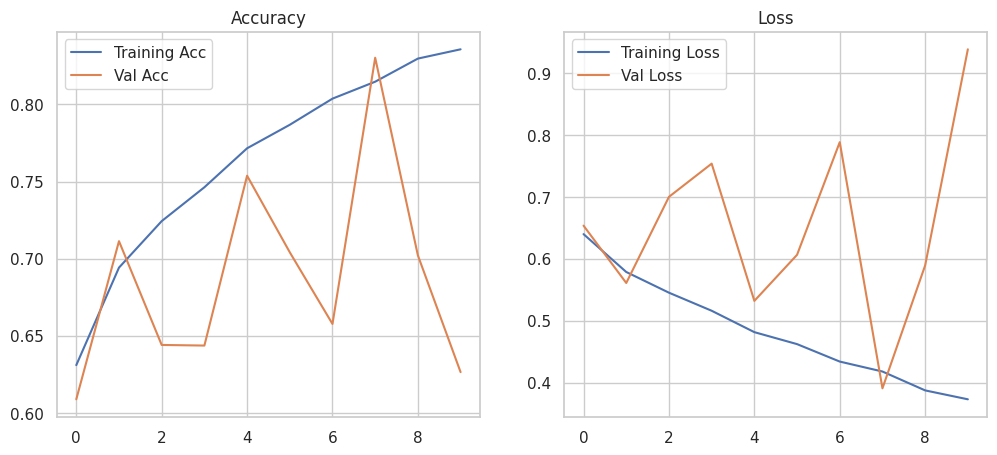

In [30]:
from train.train_cnn import plot_results
plot_results(history)

#### Evaluate Model with test dataset

In [31]:
from train.train_util import load_test_dataset
test_ds= load_test_dataset()

Found 2495 files belonging to 2 classes.


In [32]:
from evaluate.evaluate import evaluate_cnn
y_true, y_probs, y_pred=evaluate_cnn(model=cnn_model,test_ds=test_ds)

2026-02-18 01:14:23.611321: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


78/78 ━━━━━━━━━━━━━━━━━━━━ 17s 213ms/step


#### Confusion Matrix

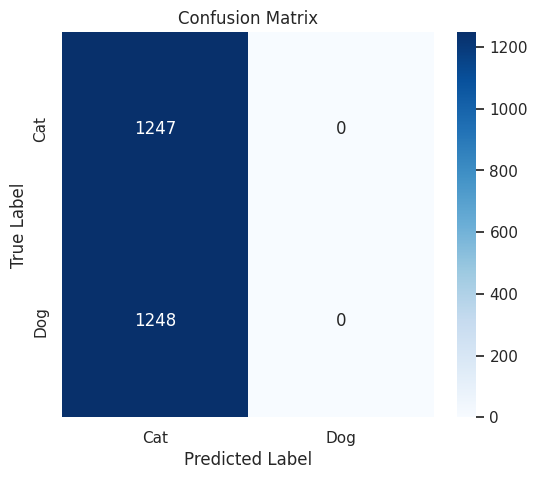

In [33]:
from evaluate.evaluate import plot_cnn_confusion_matrix
plot_cnn_confusion_matrix(y_true, y_pred)

#### ROC Curve and AUC

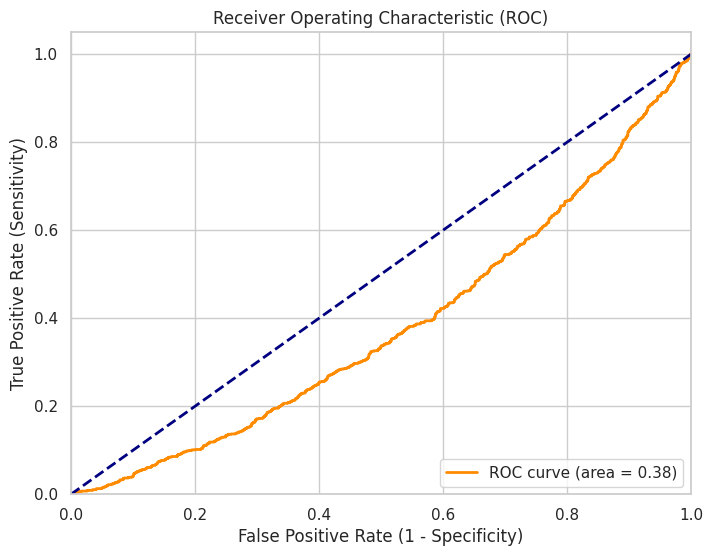

In [34]:
from evaluate.evaluate import plot_cnn_roc_curve
roc_auc=plot_cnn_roc_curve(y_true,y_probs)

#### Summary Metrics Table

------------------------------
Final Test Evaluation:
------------------------------
Accuracy:  0.4998
Precision: 0.0000
Recall:    0.0000
F1-Score:  0.0000
ROC-AUC:   0.3825
------------------------------


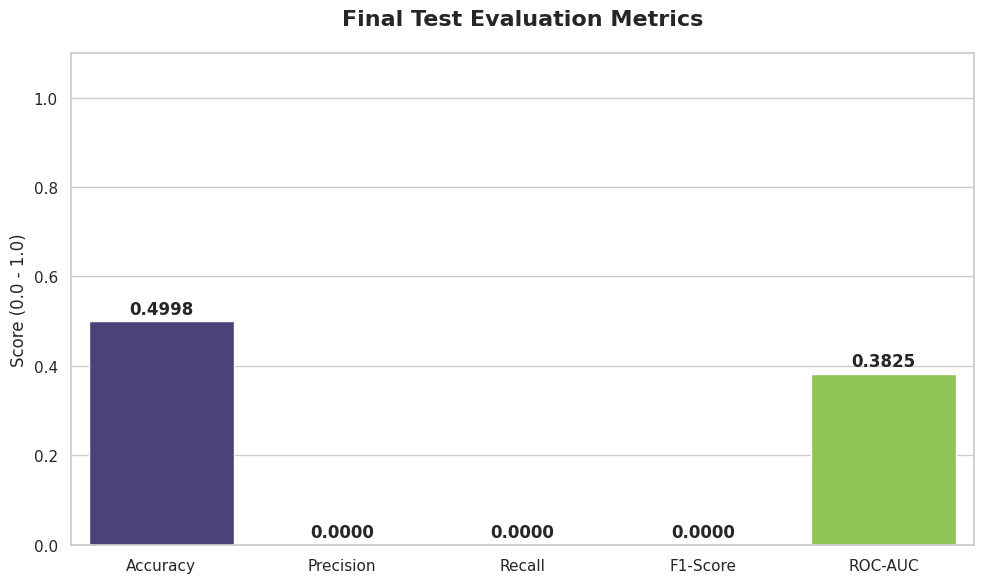

In [35]:
from evaluate.evaluate import plot_cnn_summary
metrics_values=plot_cnn_summary(y_true, y_pred, roc_auc)


### Experiment Tracking

Integrate MLflow (or a similar tool) for experiment tracking. Log parameters, metrics, artifacts, and plots for all runs.

#### Logging Plots as MLflow Artifacts

##### Initializing MLFlow

In [36]:
# from evaluate.experiment_tracking import init_mlflow, mlflow_end_run

# init_mlflow()
# mlflow_end_run()

##### Log EDA plots

In [37]:
# from evaluate.experiment_tracking import mlflow_eda
# mlflow_eda()

##### CNN – MLflow Tracking

In [38]:
# from evaluate.experiment_tracking import mlflow_cnn

# mlflow_cnn(cnn_model=cnn_model,metrics=metrics_values)

##### End MlFlow run

In [39]:
# from evaluate.experiment_tracking import mlflow_end_run
# mlflow_end_run()

### Model Packaging & Reproducibility

##### Save CNN

In [40]:
from train.train_util import save_model
save_model("cnn_model.pkl",cnn_model)
print("CNN model saved")

CNN model saved


##### Load CNN Model (Reusability Check)

##### Reproducible Preprocessing Pipeline

In [3]:
from train.train_util import load_model
loaded_cnn_model=load_model("cnn_model.pkl")
print("CNN model loaded successfully")

CNN model loaded successfully


In [4]:
loaded_cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (32, 224, 224, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (32, 224, 224, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (32, 224, 224, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (32, 224, 224, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (32, 224, 224, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (32, 224, 224, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (32, 112, 112, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (32, 112, 112, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (32, 112, 112, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (32, 112, 112, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (32, 56, 56, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (32, 56, 56, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (32, 56, 56, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (32, 56, 56, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (32, 28, 28, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (32, 28, 28, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (32, 28, 28, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (32, 28, 28, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (32, 256)              │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, 128)              │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (32, 128)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 1)                │           12

 Total params: 423,361 (1.61 MB)

 Trainable params: 422,401 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

##### Perform Test Inference with Sample Data

In [7]:
from evaluate.evaluate import get_sample_test_data
cat_img, dog_img=get_sample_test_data()

##### CNN Prediction

In [8]:
from evaluate.evaluate import get_prediction
import os

results = [("Actual Cat", cat_img), ("Actual Dog", dog_img)]

for actual, path in results:
    pred_label, conf, prob = get_prediction(loaded_cnn_model,path)
    print(f"--- Testing {actual} ---")
    print(f"File: {os.path.basename(path)}")
    print(f"Predicted Label: {pred_label}")
    print(f"Confidence:      {conf:.2%}")
    print(f"Raw Probability: {prob:.4f}\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
--- Testing Actual Cat ---
File: 12189.jpg
Predicted Label: Cat
Confidence:      50.61%
Raw Probability: 0.4939

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
--- Testing Actual Dog ---
File: 12189.jpg
Predicted Label: Cat
Confidence:      50.42%
Raw Probability: 0.4958

